- Gradient Boost
- Hist Gradient Boost
- Cat Boost

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("eye_tracking_dataset_2.csv")

In [3]:
X = df.drop(columns=["file", "label"])
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)  # untuk cek mapping label

['normal' 'sedang' 'tinggi']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
model = CatBoostClassifier(iterations=10)
param_grid = {'depth': [4, 6], 'learning_rate': [0.03, 0.1]}

In [6]:
grid_search_result = model.grid_search(param_grid, X, y, cv=3, plot=False)
print("Best Params:", grid_search_result['params'])

0:	learn: 1.0884068	test: 1.0889089	best: 1.0889089 (0)	total: 203ms	remaining: 1.83s
1:	learn: 1.0800390	test: 1.0808763	best: 1.0808763 (1)	total: 206ms	remaining: 822ms
2:	learn: 1.0723465	test: 1.0738401	best: 1.0738401 (2)	total: 207ms	remaining: 483ms
3:	learn: 1.0638965	test: 1.0659447	best: 1.0659447 (3)	total: 209ms	remaining: 313ms
4:	learn: 1.0558408	test: 1.0584462	best: 1.0584462 (4)	total: 210ms	remaining: 210ms
5:	learn: 1.0466928	test: 1.0499593	best: 1.0499593 (5)	total: 212ms	remaining: 141ms
6:	learn: 1.0400246	test: 1.0452866	best: 1.0452866 (6)	total: 213ms	remaining: 91.4ms
7:	learn: 1.0305280	test: 1.0351513	best: 1.0351513 (7)	total: 215ms	remaining: 53.7ms
8:	learn: 1.0245976	test: 1.0305107	best: 1.0305107 (8)	total: 216ms	remaining: 24ms
9:	learn: 1.0170109	test: 1.0239123	best: 1.0239123 (9)	total: 217ms	remaining: 0us

bestTest = 1.023912282
bestIteration = 9

0:	loss: 1.0239123	best: 1.0239123 (0)	total: 343ms	remaining: 1.03s
0:	learn: 1.0654064	test: 1.0

In [7]:
model = CatBoostClassifier(iterations=10, depth=4, learning_rate=0.1)
model.fit(X_train, y_train)

0:	learn: 1.0659221	total: 2.29ms	remaining: 20.7ms
1:	learn: 1.0349984	total: 4.3ms	remaining: 17.2ms
2:	learn: 1.0113754	total: 6.21ms	remaining: 14.5ms
3:	learn: 0.9906965	total: 9.47ms	remaining: 14.2ms
4:	learn: 0.9661761	total: 10.9ms	remaining: 10.9ms
5:	learn: 0.9418714	total: 12.3ms	remaining: 8.17ms
6:	learn: 0.9218214	total: 14.4ms	remaining: 6.18ms
7:	learn: 0.9061440	total: 17.6ms	remaining: 4.39ms
8:	learn: 0.8899763	total: 19.9ms	remaining: 2.21ms
9:	learn: 0.8784370	total: 22ms	remaining: 0us


CatBoostClassifier(depth=4, iterations=10, learning_rate=0.1)

In [8]:
print(type(model))
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)
print(classification_report(y_test, y_pred))

<class 'catboost.core.CatBoostClassifier'>
Test Accuracy: 0.5961538461538461
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.60      0.90      0.72        30
           2       0.57      0.36      0.44        11

    accuracy                           0.60        52
   macro avg       0.39      0.42      0.39        52
weighted avg       0.47      0.60      0.51        52



c:\Users\myoga\Documents\Politeknik Negeri Jember\Mahayoga Semester 6\Projek TA\_PYTHON_tobii-data-processing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\myoga\Documents\Politeknik Negeri Jember\Mahayoga Semester 6\Projek TA\_PYTHON_tobii-data-processing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\myoga\Documents\Politeknik Negeri Jember\Mahayoga Semester 6\Projek TA\_PYTHON_tobii-data-processing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1

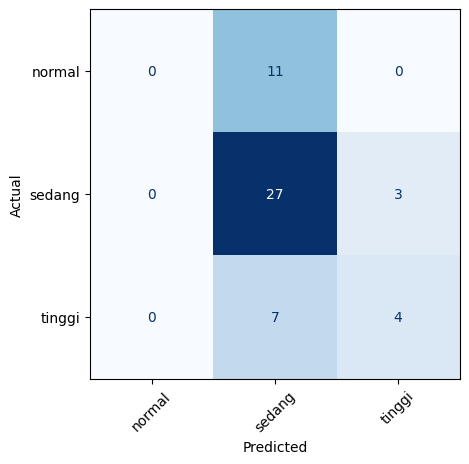

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap=plt.cm.Blues, values_format="d", xticks_rotation=45, colorbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()